In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     379   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        60   (2094, 964)   float32   


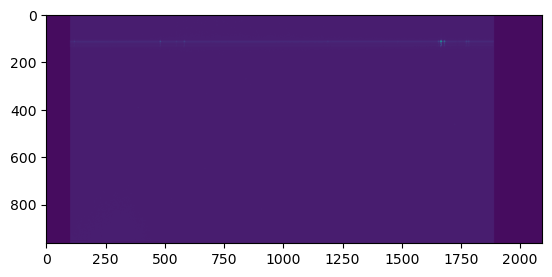

In [3]:
plt.imshow(image)

In [4]:
image_cut = image[70:170, 100:1900]

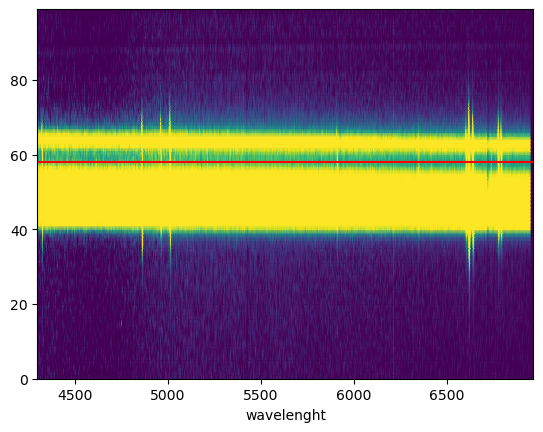

In [5]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')
plt.axhline(58, color='red')

We know that redshift and wavelenghts are related in this way:
$\lambda_{obs} = \lambda_{em}*(1+z)$ \\
So if we want:
- $\lambda_{obs}(H\alpha)$ = 6563 * (1+0.03144) = 6769 AA
- $\lambda_{obs}(H\beta)$ = 4861 * (1+0.03144) = 5014 AA
- $\lambda_{obs}([NII])$ = 6548 * (1+0.03144) = 6754 AA
- $\lambda_{obs}([SII])$ = 6717 * (1+0.03144) = 6928 AA
- $\lambda_{obs}([OIII])$ = 4959 * (1+0.03144) = 5115 AA


## Continuum 6500 AA

Text(0.5, 1.0, 'Continuum 6500 A')

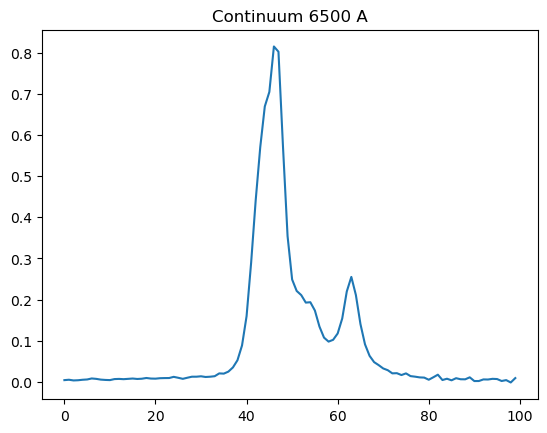

In [6]:
mask = (wavelenghts > 6490)*(wavelenghts < 6510)
image_6500 = image_cut[:, mask] #cut su 6500 A
radial_profile = np.mean(image_6500, axis = 1)
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile)
plt.title('Continuum 6500 A')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

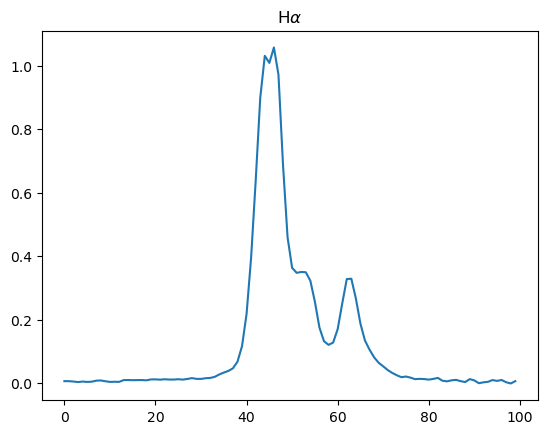

In [7]:
mask_HA = (wavelenghts > 6759)*(wavelenghts < 6779)
image_HA = image_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')

The fit gives us these parameters: A = 1.26, A2 = 0.26, mu = 45.48, mu2 = 62.57, As = 0.14, r_eff = 49.09, n = 0.03


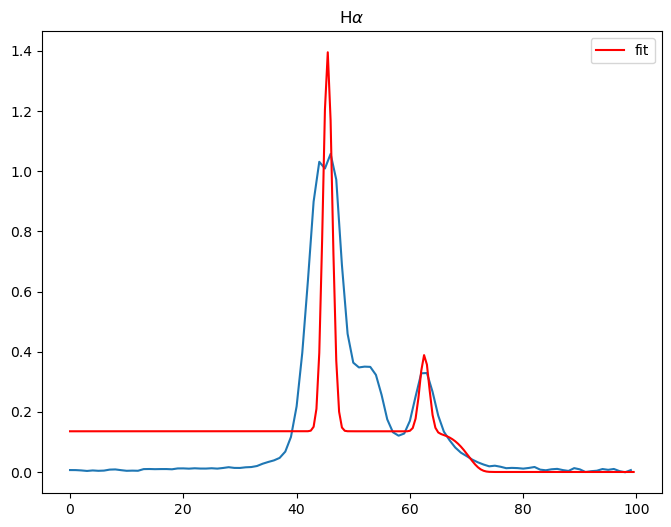

In [19]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 1.953/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[1, 0.3, 40, 70, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()

plt.show()

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

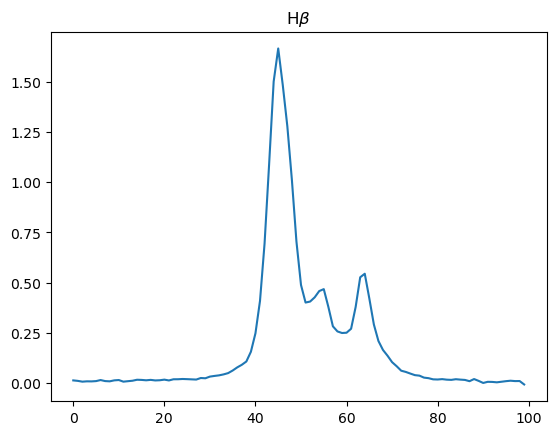

In [9]:
mask_HB = (wavelenghts > 5004)*(wavelenghts < 5024)
image_HB = image_cut[:, mask_HB] #cut su 4977 A
radial_profile_HB = np.mean(image_HB, axis = 1)
plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')

The fit gives us these parameters: A = 1.93, A2 = 0.45, mu = 45.05, mu2 = 63.62, As = 0.19, r_eff = 50.28, n = 0.03


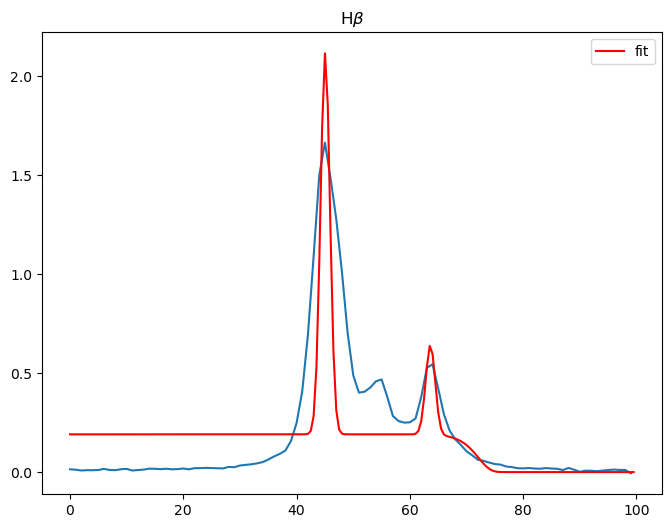

In [10]:
params, covariance = curve_fit(model, x_axes, radial_profile_HB, p0=[1.25, 0.6, 44, 65, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [NII]

Text(0.5, 1.0, '[NII]')

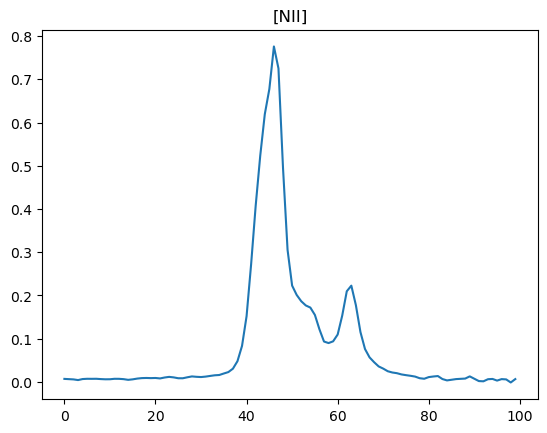

In [11]:
mask_NII = (wavelenghts > 6744)*(wavelenghts < 6764)
image_NII = image_cut[:, mask_NII] 
radial_profile_NII = np.mean(image_NII, axis = 1)
plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')

The fit gives us these parameters: A = 0.91, A2 = 0.17, mu = 46.07, mu2 = 62.70, As = 0.09, r_eff = 48.84, n = 0.03


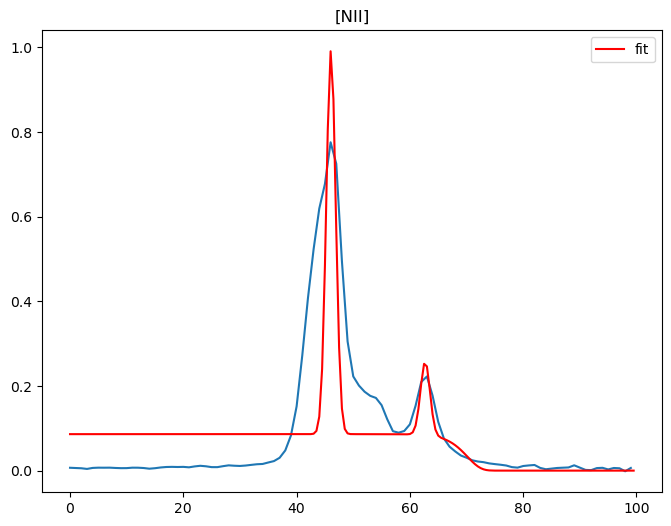

In [12]:
params, covariance = curve_fit(model, x_axes, radial_profile_NII, p0=[0.7, 0.2, 42, 65, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [SII]

Text(0.5, 1.0, '[SII]')

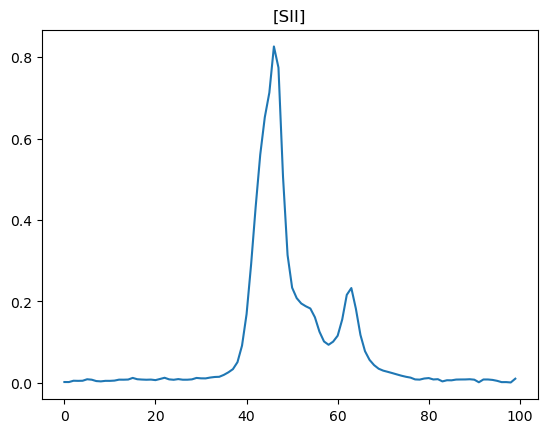

In [13]:
mask_SII = (wavelenghts > 6918)*(wavelenghts < 6938)
image_SII = image_cut[:, mask_SII] #cut su 6877 A
radial_profile_SII = np.mean(image_SII, axis = 1)
plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')

The fit gives us these parameters: A = 0.97, A2 = 0.18, mu = 46.09, mu2 = 62.72, As = 0.09, r_eff = 48.74, n = 0.03


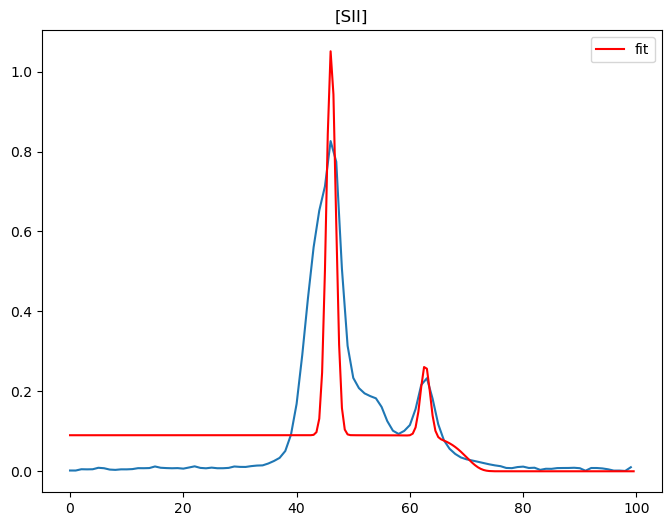

In [14]:
params, covariance = curve_fit(model, x_axes, radial_profile_SII, p0=[0.8, 0.25, 42, 65, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [OIII]

Text(0.5, 1.0, '[OIII]')

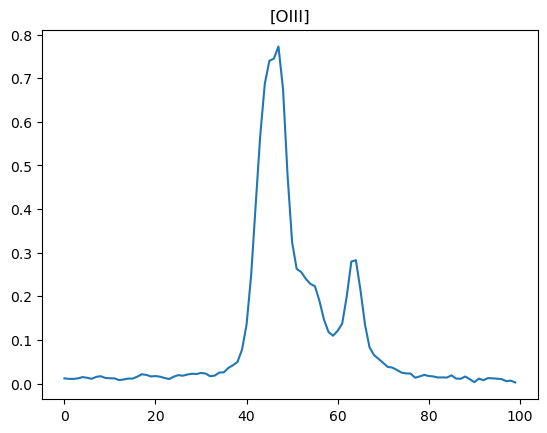

In [15]:
mask_OIII = (wavelenghts > 5105)*(wavelenghts < 5125)
image_OIII = image_cut[:, mask_OIII] #cut su 5077 A
radial_profile_OIII = np.mean(image_OIII, axis = 1)
plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')

The fit gives us these parameters: A = 0.90, A2 = 0.23, mu = 46.38, mu2 = 63.58, As = 0.11, r_eff = 49.66, n = 0.04


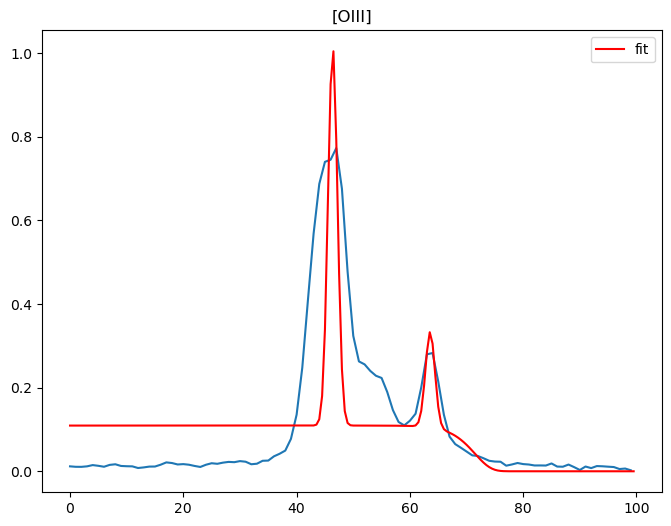

In [16]:
params, covariance = curve_fit(model, x_axes, radial_profile_OIII, p0=[0.7, 0.3, 42, 65, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()